Epoch 0, Loss: 0.6914
Epoch 100, Loss: 0.4931
Epoch 200, Loss: 0.2269
Epoch 300, Loss: 0.1412
Epoch 400, Loss: 0.1092
Epoch 500, Loss: 0.0933
Epoch 600, Loss: 0.0839
Epoch 700, Loss: 0.0777
Epoch 800, Loss: 0.0733
Epoch 900, Loss: 0.0699

Test Accuracy: 0.9824561403508771


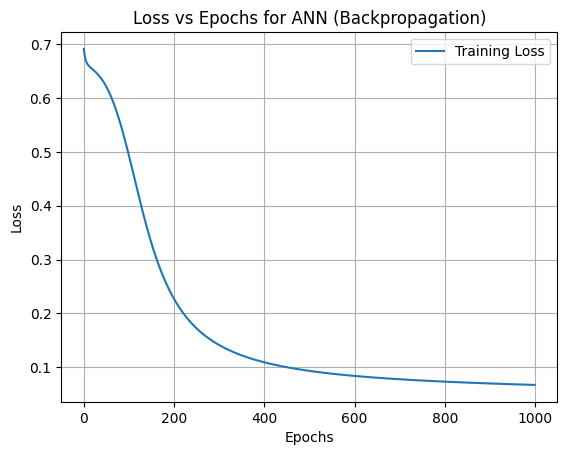

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Load and preprocess data
# -------------------------------
data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1, 1)  # make column vector

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# -------------------------------
# Step 2: Define Neural Network
# -------------------------------
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.lr = lr
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y, output):
        m = X.shape[0]

        dZ2 = output - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.sigmoid_derivative(self.A1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        for i in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            # compute loss
            loss = -np.mean(y*np.log(output+1e-8) + (1-y)*np.log(1-output+1e-8))
            self.loss_history.append(loss)

            if i % 100 == 0:
                print(f"Epoch {i}, Loss: {loss:.4f}")

    def predict(self, X):
        output = self.forward(X)
        return (output > 0.5).astype(int)


# -------------------------------
# Step 3: Train and Test
# -------------------------------
nn = NeuralNetwork(input_size=X.shape[1], hidden_size=16, output_size=1, lr=0.1)
nn.train(X_train, y_train, epochs=1000)

y_pred = nn.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------------
# Step 4: Plot Loss vs Epochs
# -------------------------------
plt.plot(nn.loss_history, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs for ANN (Backpropagation)")
plt.legend()
plt.grid(True)
plt.show()
